# Experiment Results Analysis

这个 Notebook 用于分析 `experiment_results.csv`，并输出论文常用图表：
- TRE / RE 在不同投影模式下的分布
- testPoint 距离效应（距离 vs TRE / RE）
- 角度效应（Angle M1-M2, M3-M1, M3-M2）
- Perspective vs Orthographic 配对比较
- 不同体数据（`input_volume`）之间的差异

运行完成后，图像会保存到 `Analysis/figures/`。

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

from IPython.display import display


In [2]:
PROJECT_ROOT = Path.cwd()
ANALYSIS_DIR = PROJECT_ROOT / 'Analysis'
FIG_DIR = ANALYSIS_DIR / 'figures'
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
EXP_DIR = PROJECT_ROOT / 'experiment' / 'experiment_results.csv'
if not EXP_DIR.exists():
    EXP_DIR = PROJECT_ROOT.parent / 'experiment' / 'experiment_results.csv'
# 手动指定 CSV（如不指定则自动寻找最新的 experiment_results.csv）
manual_csv_path = EXP_DIR # 例如 r'D:\\\\Data\\\\experiment_results.csv'

if manual_csv_path:
    csv_path = Path(manual_csv_path)
else:
    candidates = list(PROJECT_ROOT.rglob('experiment_results.csv'))
    if not candidates:
        candidates = list(PROJECT_ROOT.rglob('*.csv'))
    if not candidates:
        raise FileNotFoundError('未找到 CSV 文件，请设置 manual_csv_path。')
    csv_path = max(candidates, key=lambda p: p.stat().st_mtime)

print(f'CSV path: {csv_path}')
print(f'Figure output dir: {FIG_DIR}')


CSV path: d:\CodingHHW\Biplane\experiment\experiment_results.csv
Figure output dir: d:\CodingHHW\Biplane\Analysis\Analysis\figures


In [4]:
df_raw = pd.read_csv(csv_path, encoding='utf-8-sig')
df = df_raw.copy()

if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

numeric_cols = [
    'shot2_angle_deg', 'shot3_angle_m3_m1_deg', 'shot3_angle_m3_m2_deg',
    'tre_value_mm', 'reprojection_error_px', 'ray_gap_mm',
    'markers_sorted', 'perspective_calibration_ready', 'orthographic_calibration_ready',
    'shot1_available', 'shot2_available', 'shot3_available',
    'testpoint_x', 'testpoint_y', 'testpoint_z',
    'testpoint_marker_distance_t1_mm', 'testpoint_marker_distance_t2_mm',
    'testpoint_marker_distance_t3_mm', 'testpoint_marker_distance_mean_mm',
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'projection_mode' in df.columns:
    mode = df['projection_mode'].astype(str).str.strip().str.lower()
    df['projection_mode'] = mode.map({
        'perspective': 'Perspective',
        'orthographic': 'Orthographic',
    }).fillna(mode.str.title())
else:
    df['projection_mode'] = 'Unknown'

if 'input_volume' not in df.columns:
    df['input_volume'] = 'Unknown'
df['input_volume'] = df['input_volume'].fillna('Unknown').astype(str)

if 'testpoint_marker_distance_mean_mm' not in df.columns:
    dist_cols = [c for c in [
        'testpoint_marker_distance_t1_mm',
        'testpoint_marker_distance_t2_mm',
        'testpoint_marker_distance_t3_mm',
    ] if c in df.columns]
    if dist_cols:
        df['testpoint_marker_distance_mean_mm'] = df[dist_cols].mean(axis=1, skipna=True)

dist_col = 'testpoint_marker_distance_mean_mm'
if dist_col in df.columns and df[dist_col].notna().sum() >= 9:
    df['distance_group'] = pd.qcut(df[dist_col], q=3, labels=['Near', 'Mid', 'Far'], duplicates='drop')
elif dist_col in df.columns and df[dist_col].notna().sum() >= 3:
    df['distance_group'] = pd.cut(df[dist_col], bins=3, labels=['Near', 'Mid', 'Far'])
else:
    df['distance_group'] = np.nan

quality_mask = pd.Series(True, index=df.index)
for col in ['markers_sorted', 'shot1_available', 'shot2_available', 'shot3_available']:
    if col in df.columns:
        quality_mask &= df[col].fillna(0).astype(float) > 0

df_q = df.loc[quality_mask].copy()

print(f'Raw rows: {len(df_raw)}')
print(f'Quality rows: {len(df_q)}')
print(f'Columns: {len(df_q.columns)}')


Raw rows: 206
Quality rows: 206
Columns: 38


In [5]:
summary = pd.DataFrame({
    'n_rows': [len(df_q)],
    'n_modes': [df_q['projection_mode'].nunique(dropna=True)],
    'n_volumes': [df_q['input_volume'].nunique(dropna=True)],
    'tre_mean_mm': [df_q['tre_value_mm'].mean() if 'tre_value_mm' in df_q else np.nan],
    'tre_std_mm': [df_q['tre_value_mm'].std() if 'tre_value_mm' in df_q else np.nan],
    're_mean_px': [df_q['reprojection_error_px'].mean() if 'reprojection_error_px' in df_q else np.nan],
    're_std_px': [df_q['reprojection_error_px'].std() if 'reprojection_error_px' in df_q else np.nan],
})
display(summary.round(4))

print('Count by projection mode:')
display(df_q['projection_mode'].value_counts(dropna=False).to_frame('count'))

print('Count by input volume (top 10):')
display(df_q['input_volume'].value_counts(dropna=False).head(10).to_frame('count'))

display(df_q.head())


,n_rows,n_modes,n_volumes,tre_mean_mm,tre_std_mm,re_mean_px,re_std_px
0,206,2,2,0.1914,0.1402,0.1906,0.193


Count by projection mode:


,count
projection_mode,
Perspective,132
Orthographic,74


Count by input volume (top 10):


,count
input_volume,
CTChest,145
Panoramix-cropped,61


,timestamp,csv_output_path,input_volume,projection_mode,projection_mode_status,markers_sorted,perspective_calibration_ready,orthographic_calibration_ready,shot1_available,shot2_available,...,testpoint_y,testpoint_z,testpoint_marker_distance_t1_mm,testpoint_marker_distance_t2_mm,testpoint_marker_distance_t3_mm,testpoint_marker_distance_mean_mm,debug_visualization,debug_plane_scale,debug_ray_scale,distance_group
0,2026-03-01 17:40:20+08:00,C:\Users\80758\AppData\Local\Temp\Slicer\Bipla...,CTChest,Perspective,Current mode: Perspective,1,1,0,1,1,...,90.177864,-129.802170,79.133727,92.570916,83.167227,84.957290,0,6.0,10.0,Near
1,2026-03-01 17:46:38+08:00,C:\Users\80758\AppData\Local\Temp\Slicer\Bipla...,CTChest,Perspective,Current mode: Perspective,1,1,0,1,1,...,90.849548,-183.689804,41.994902,61.555962,38.666548,47.405804,0,6.0,10.0,Near
2,2026-03-01 17:49:52+08:00,C:\Users\80758\AppData\Local\Temp\Slicer\Bipla...,CTChest,Perspective,Current mode: Perspective,1,1,0,1,1,...,58.072670,-39.549397,173.679602,183.093313,178.461762,178.411559,0,6.0,10.0,Mid
3,2026-03-01 17:51:14+08:00,C:\Users\80758\AppData\Local\Temp\Slicer\Bipla...,CTChest,Perspective,Current mode: Perspective,1,1,0,1,1,...,69.253166,-167.190079,114.213280,134.325077,112.703530,120.413962,0,6.0,10.0,Near
4,2026-03-01 17:52:57+08:00,C:\Users\80758\AppData\Local\Temp\Slicer\Bipla...,CTChest,Perspective,Current mode: Perspective,1,1,0,1,1,...,54.932411,-93.910095,153.413872,169.995424,155.643575,159.684290,0,6.0,10.0,Mid


In [6]:
def save_fig(fig, filename: str):
    out = FIG_DIR / filename
    fig.savefig(out, dpi=300, bbox_inches='tight')
    print(f'Saved: {out}')

def identity_line(ax, values):
    v = np.asarray(values, dtype=float)
    if len(v) == 0:
        return
    lo, hi = np.nanmin(v), np.nanmax(v)
    if not np.isfinite(lo) or not np.isfinite(hi):
        return
    ax.plot([lo, hi], [lo, hi], '--', color='black', linewidth=1)


Saved: d:\CodingHHW\Biplane\Analysis\Analysis\figures\01_error_distribution_by_mode.png


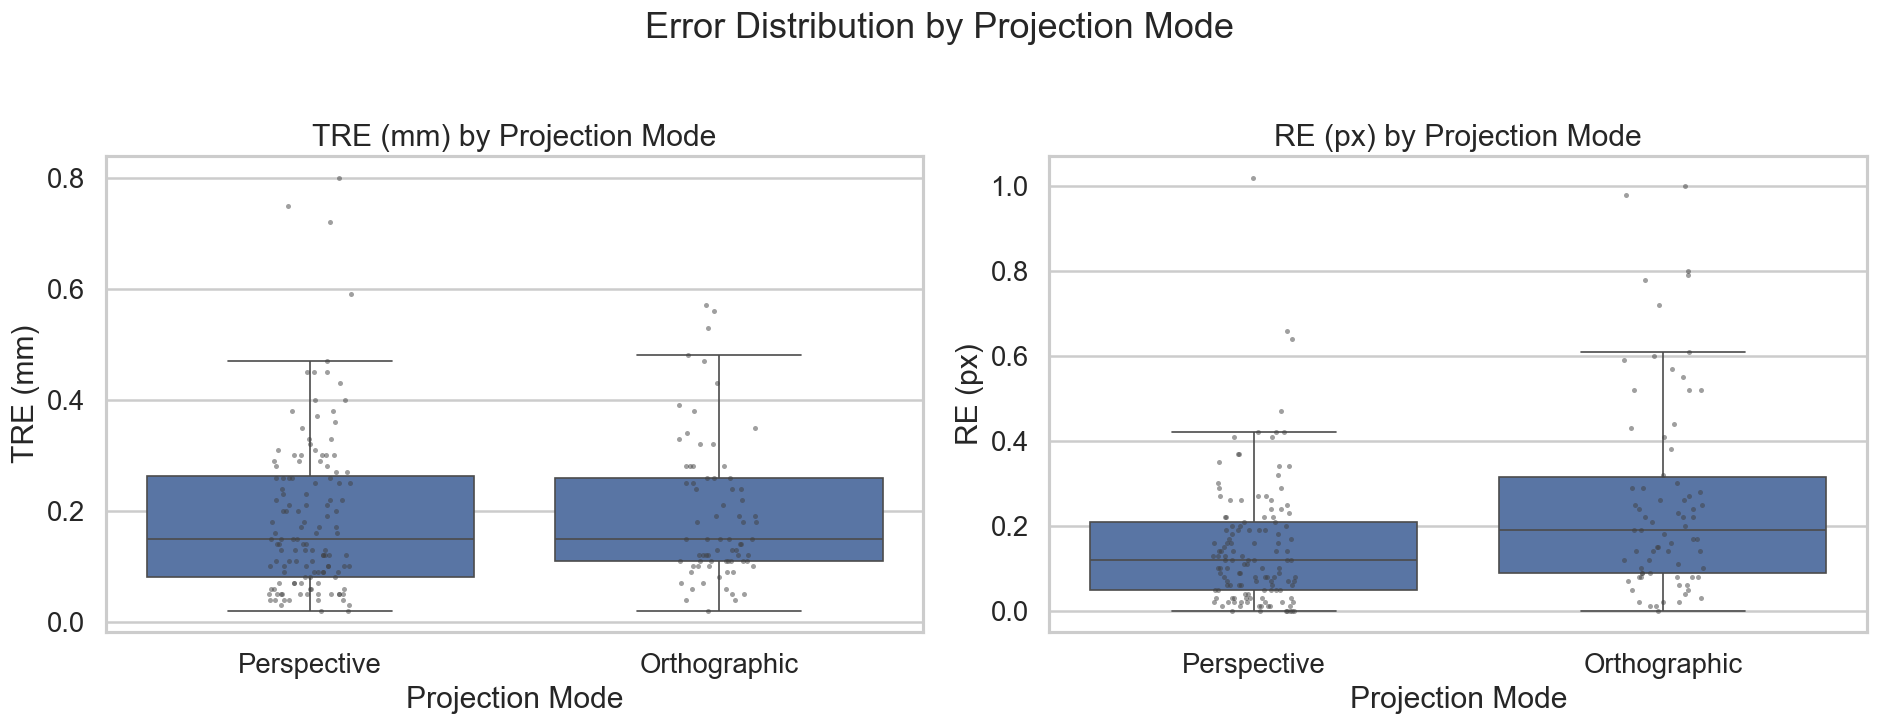

In [7]:
# 图1：TRE/RE 在不同模式下的分布
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_specs = [
    ('tre_value_mm', 'TRE (mm)'),
    ('reprojection_error_px', 'RE (px)'),
]

for ax, (col, ylabel) in zip(axes, plot_specs):
    if col not in df_q.columns or df_q[col].notna().sum() == 0:
        ax.text(0.5, 0.5, f'No data: {col}', ha='center', va='center')
        ax.set_axis_off()
        continue
    sns.boxplot(data=df_q, x='projection_mode', y=col, ax=ax, fliersize=0)
    sns.stripplot(data=df_q, x='projection_mode', y=col, ax=ax, color='0.25', alpha=0.5, size=3)
    ax.set_xlabel('Projection Mode')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} by Projection Mode')

fig.suptitle('Error Distribution by Projection Mode', y=1.02)
fig.tight_layout()
save_fig(fig, '01_error_distribution_by_mode.png')
plt.show()


Saved: d:\CodingHHW\Biplane\Analysis\Analysis\figures\02_distance_effect_scatter.png


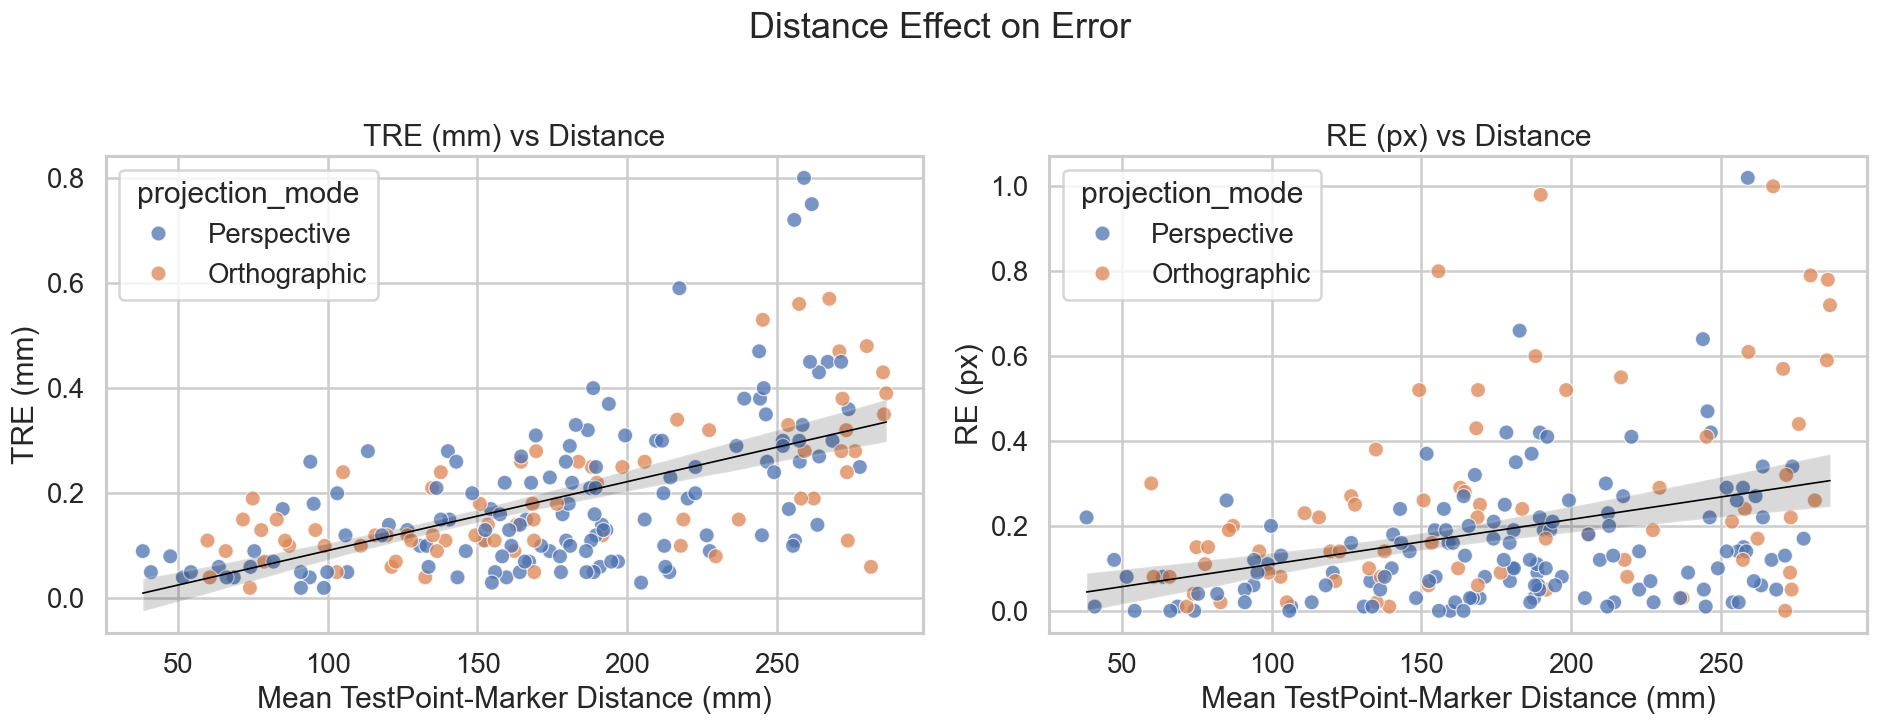

Saved: d:\CodingHHW\Biplane\Analysis\Analysis\figures\03_distance_group_boxplots.png


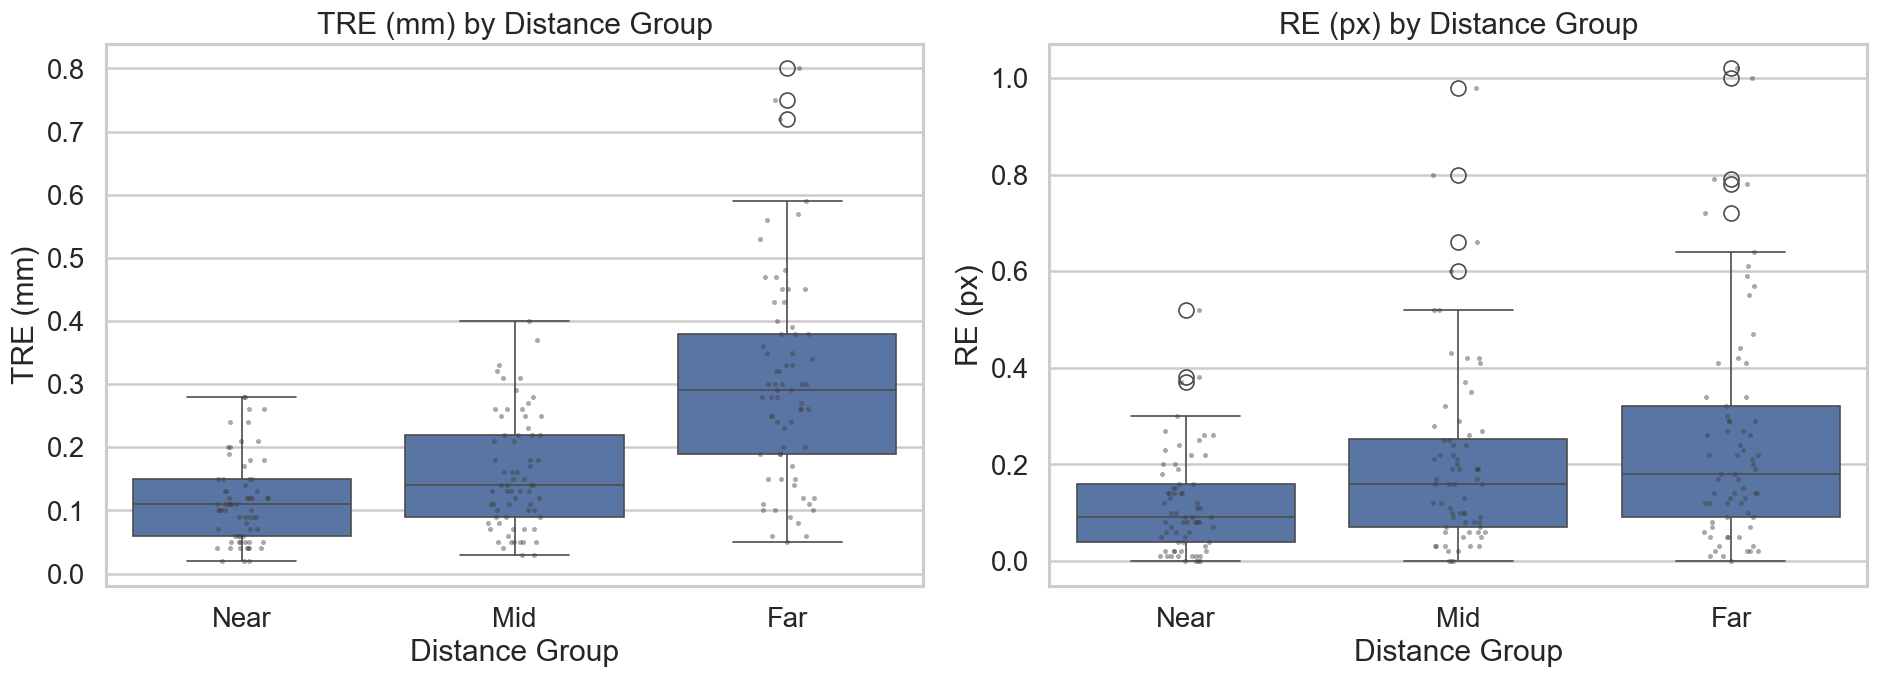

In [8]:
# 图2：距离效应（距离 vs TRE/RE）
dist_col = 'testpoint_marker_distance_mean_mm'
if dist_col in df_q.columns and df_q[dist_col].notna().sum() >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, (ycol, ylabel) in zip(axes, [('tre_value_mm', 'TRE (mm)'), ('reprojection_error_px', 'RE (px)')]):
        sub = df_q[[dist_col, ycol, 'projection_mode']].dropna()
        if len(sub) < 3:
            ax.text(0.5, 0.5, f'Insufficient data: {ycol}', ha='center', va='center')
            ax.set_axis_off()
            continue
        sns.scatterplot(data=sub, x=dist_col, y=ycol, hue='projection_mode', alpha=0.75, ax=ax)
        sns.regplot(data=sub, x=dist_col, y=ycol, scatter=False, color='black', line_kws={'lw': 1}, ax=ax)
        ax.set_xlabel('Mean TestPoint-Marker Distance (mm)')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel} vs Distance')

    fig.suptitle('Distance Effect on Error', y=1.02)
    fig.tight_layout()
    save_fig(fig, '02_distance_effect_scatter.png')
    plt.show()

    if 'distance_group' in df_q.columns and df_q['distance_group'].notna().sum() > 0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        for ax, (ycol, ylabel) in zip(axes, [('tre_value_mm', 'TRE (mm)'), ('reprojection_error_px', 'RE (px)')]):
            sub = df_q[['distance_group', ycol]].dropna()
            if len(sub) < 3:
                ax.text(0.5, 0.5, f'Insufficient data: {ycol}', ha='center', va='center')
                ax.set_axis_off()
                continue
            sns.boxplot(data=sub, x='distance_group', y=ycol, ax=ax, order=['Near', 'Mid', 'Far'])
            sns.stripplot(data=sub, x='distance_group', y=ycol, ax=ax, color='0.25', alpha=0.45, size=3, order=['Near', 'Mid', 'Far'])
            ax.set_xlabel('Distance Group')
            ax.set_ylabel(ylabel)
            ax.set_title(f'{ylabel} by Distance Group')

        fig.tight_layout()
        save_fig(fig, '03_distance_group_boxplots.png')
        plt.show()
else:
    print('未检测到可用的 testpoint_marker_distance_mean_mm 数据，跳过距离效应图。')


In [ ]:
# 图3：角度效应（3个角度 × 2个误差）
angle_cols = [
    ('shot2_angle_deg', 'Angle M1-M2 (deg)'),
    ('shot3_angle_m3_m1_deg', 'Angle M3-M1 (deg)'),
    ('shot3_angle_m3_m2_deg', 'Angle M3-M2 (deg)'),
]
metric_cols = [('tre_value_mm', 'TRE (mm)'), ('reprojection_error_px', 'RE (px)')]

fig, axes = plt.subplots(3, 2, figsize=(14, 18))
for i, (xcol, xlabel) in enumerate(angle_cols):
    for j, (ycol, ylabel) in enumerate(metric_cols):
        ax = axes[i, j]
        if xcol not in df_q.columns or ycol not in df_q.columns:
            ax.text(0.5, 0.5, f'Missing: {xcol} or {ycol}', ha='center', va='center')
            ax.set_axis_off()
            continue
        sub = df_q[[xcol, ycol, 'projection_mode']].dropna()
        if len(sub) < 3:
            ax.text(0.5, 0.5, f'Insufficient data: {xcol}', ha='center', va='center')
            ax.set_axis_off()
            continue
        sns.scatterplot(data=sub, x=xcol, y=ycol, hue='projection_mode', alpha=0.75, ax=ax)
        sns.regplot(data=sub, x=xcol, y=ycol, scatter=False, color='black', line_kws={'lw': 1}, ax=ax)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel} vs {xlabel}')

fig.suptitle('Angle Effects on TRE and RE', y=1.01)
fig.tight_layout()
save_fig(fig, '04_angle_effects.png')
plt.show()


In [ ]:
# 图4：Perspective vs Orthographic 配对比较
pair_key_candidates = [
    'input_volume',
    'testpoint_x', 'testpoint_y', 'testpoint_z',
    'shot2_angle_deg', 'shot3_angle_m3_m1_deg', 'shot3_angle_m3_m2_deg',
]

pair_df = df_q.copy()
available_keys = [c for c in pair_key_candidates if c in pair_df.columns]

# 数值键取四舍五入，减少浮点噪声导致的配对失败
key_cols = []
for col in available_keys:
    if np.issubdtype(pair_df[col].dtype, np.number):
        rc = f'{col}_r'
        pair_df[rc] = pair_df[col].round(2)
        key_cols.append(rc)
    else:
        key_cols.append(col)

if 'projection_mode' in pair_df.columns and {'Perspective', 'Orthographic'}.issubset(set(pair_df['projection_mode'].dropna().unique())) and len(key_cols) >= 4:
    grouped = pair_df.groupby(key_cols + ['projection_mode'], as_index=False)[['tre_value_mm', 'reprojection_error_px']].mean()
    pivot_tre = grouped.pivot_table(index=key_cols, columns='projection_mode', values='tre_value_mm', aggfunc='mean')
    pivot_re = grouped.pivot_table(index=key_cols, columns='projection_mode', values='reprojection_error_px', aggfunc='mean')

    paired = pd.DataFrame({
        'tre_perspective': pivot_tre.get('Perspective'),
        'tre_orthographic': pivot_tre.get('Orthographic'),
        're_perspective': pivot_re.get('Perspective'),
        're_orthographic': pivot_re.get('Orthographic'),
    }).dropna(how='all').dropna()

    print(f'Paired rows: {len(paired)}')
    display(paired.head())

    if len(paired) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        sns.scatterplot(data=paired, x='tre_orthographic', y='tre_perspective', ax=axes[0])
        identity_line(axes[0], np.r_[paired['tre_orthographic'].values, paired['tre_perspective'].values])
        axes[0].set_xlabel('Orthographic TRE (mm)')
        axes[0].set_ylabel('Perspective TRE (mm)')
        axes[0].set_title('Paired TRE: Perspective vs Orthographic')

        sns.scatterplot(data=paired, x='re_orthographic', y='re_perspective', ax=axes[1])
        identity_line(axes[1], np.r_[paired['re_orthographic'].values, paired['re_perspective'].values])
        axes[1].set_xlabel('Orthographic RE (px)')
        axes[1].set_ylabel('Perspective RE (px)')
        axes[1].set_title('Paired RE: Perspective vs Orthographic')

        fig.tight_layout()
        save_fig(fig, '05_paired_mode_comparison_scatter.png')
        plt.show()

        paired['delta_tre'] = paired['tre_perspective'] - paired['tre_orthographic']
        paired['delta_re'] = paired['re_perspective'] - paired['re_orthographic']

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        sns.histplot(paired['delta_tre'], kde=True, ax=axes[0])
        axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
        axes[0].set_title('Delta TRE (Perspective - Orthographic)')
        axes[0].set_xlabel('Delta TRE (mm)')

        sns.histplot(paired['delta_re'], kde=True, ax=axes[1])
        axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
        axes[1].set_title('Delta RE (Perspective - Orthographic)')
        axes[1].set_xlabel('Delta RE (px)')

        fig.tight_layout()
        save_fig(fig, '06_paired_mode_comparison_delta_hist.png')
        plt.show()

        if SCIPY_AVAILABLE and len(paired) >= 6:
            try:
                w_tre = stats.wilcoxon(paired['delta_tre'])
                w_re = stats.wilcoxon(paired['delta_re'])
                print('Wilcoxon signed-rank test:')
                print(f'  TRE p-value = {w_tre.pvalue:.6g}')
                print(f'  RE  p-value = {w_re.pvalue:.6g}')
            except Exception as e:
                print(f'Wilcoxon failed: {e}')
else:
    print('无法建立稳定的 Perspective/Orthographic 配对样本，跳过配对比较图。')


In [ ]:
# 图5：不同体数据对比（仅显示样本量最多的前8个）
if 'input_volume' in df_q.columns and df_q['input_volume'].nunique() > 1:
    top_volumes = df_q['input_volume'].value_counts().head(8).index.tolist()
    sub = df_q[df_q['input_volume'].isin(top_volumes)].copy()

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.boxplot(data=sub, x='input_volume', y='tre_value_mm', ax=axes[0], fliersize=0)
    sns.stripplot(data=sub, x='input_volume', y='tre_value_mm', ax=axes[0], color='0.3', alpha=0.4, size=2)
    axes[0].set_title('TRE by Input Volume')
    axes[0].set_xlabel('Input Volume')
    axes[0].set_ylabel('TRE (mm)')
    axes[0].tick_params(axis='x', rotation=30)

    sns.boxplot(data=sub, x='input_volume', y='reprojection_error_px', ax=axes[1], fliersize=0)
    sns.stripplot(data=sub, x='input_volume', y='reprojection_error_px', ax=axes[1], color='0.3', alpha=0.4, size=2)
    axes[1].set_title('RE by Input Volume')
    axes[1].set_xlabel('Input Volume')
    axes[1].set_ylabel('RE (px)')
    axes[1].tick_params(axis='x', rotation=30)

    fig.tight_layout()
    save_fig(fig, '07_volume_comparison.png')
    plt.show()
else:
    print('只有一个 input_volume 或缺少该列，跳过体数据对比图。')


In [ ]:
# 导出清洗后数据与统计摘要
clean_csv = ANALYSIS_DIR / 'experiment_results_cleaned.csv'
summary_csv = ANALYSIS_DIR / 'analysis_summary.csv'

df_q.to_csv(clean_csv, index=False, encoding='utf-8-sig')
summary.round(6).to_csv(summary_csv, index=False, encoding='utf-8-sig')

print(f'Cleaned data saved: {clean_csv}')
print(f'Summary saved: {summary_csv}')
print(f'Figures dir: {FIG_DIR}')
